In [1]:
'''Use the mean fitness of last 2000, 1000 and 0 generations for comparison'''

'Use the mean fitness of last 2000, 1000 and 0 generations for comparison'

In [2]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

In [3]:
generation_list = []

for i in range(20002):
    generation_list.append(i)
    
print(len(generation_list))

20002


### RM

In [4]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20180510_Check the equilibrium of faculative sex_GMU =0.1_Revised sex\Data\1. N500_Diff Sexual Freq\Fitness")

In [5]:
file_20 = ['Fitness_RM_E1_N500_180510_RvSex.csv','Fitness_RM_E2_N500_180510_RvSex.csv','Fitness_RM_E5_N500_180510_RvSex.csv','Fitness_RM_E10_N500_180510_RvSex.csv', \
          'Fitness_RM_E20_N500_180510_RvSex.csv', 'Fitness_RM_E50_N500_180510_RvSex.csv', 'Fitness_RM_E100_N500_180510_RvSex.csv', \
          'Fitness_RM_E200_N500_180510_RvSex.csv', 'Fitness_RM_E500_N500_180510_RvSex.csv']

In [6]:
f20_fit_mean = []
f20_fit_std = []

f20_var_mean = []
f20_var_std = []

for i in file_20:
    f = pd.read_csv(i,dtype=str)
    
    fit_mean = []
    fit_std = []
    
    var_mean = []
    var_std = []
       
    fit_mean.extend(list(pd.Series(f.meanFit,dtype=float)))
    fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
    
    var_mean.extend(list(pd.Series(f.PopVar_Mean,dtype=float)))
    var_std.extend(list(pd.Series(f.PopVar_STD,dtype=float)))
    
    f20_fit_mean.append(fit_mean)
    f20_fit_std.append(fit_std)
    
    f20_var_mean.append(var_mean)
    f20_var_std.append(var_std)

In [7]:
def publication_figure2(axis):
    plt.rcParams.update({'font.size': 18})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(4)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')

In [8]:
def expectation(ud, freq):
    return np.exp(-ud*2*freq/45)

In [9]:
expect_value = []

freq_list = [1, 2, 5, 10, 20, 50, 100, 200, 500]

for i in freq_list:
    expect_value.append(expectation(0.1, i))

In [10]:
expect_value

[0.9955654174830928,
 0.9911505004882849,
 0.97802287248460051,
 0.95652873910302927,
 0.91494722873003098,
 0.80073740291680806,
 0.64118038842995462,
 0.41111229050718745,
 0.10836802322189586]

#### Get the mean and std of the last 2000 generations every 1000 generations

In [11]:
rm2_mean = [np.nanmean(f20_fit_mean[i][-2001::1000]) for i in range(len(f20_fit_mean))]
rm2_std = [np.nanstd(f20_fit_mean[i][-2001::1000]) for i in range(len(f20_fit_mean))]

In [12]:
rm2_mean

[0.99570862056588927,
 0.99558153792387749,
 0.99487654054942609,
 0.99427737883407019,
 0.99313556694979932,
 0.98757731541788463,
 0.97567122347614477,
 0.95244070355391408,
 0.87480921233146036]

In [13]:
rm2_std

[9.4412256638013782e-05,
 2.6881532315388504e-05,
 0.0002107341410377285,
 0.00028030885934160162,
 0.00019023221859402911,
 0.00035544342353977074,
 0.00056168810363467513,
 0.0019763970867051868,
 0.0056381244099610039]

In [15]:
def publication_figure_2(axis):
    plt.rcParams.update({'font.size': 22})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(4)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')

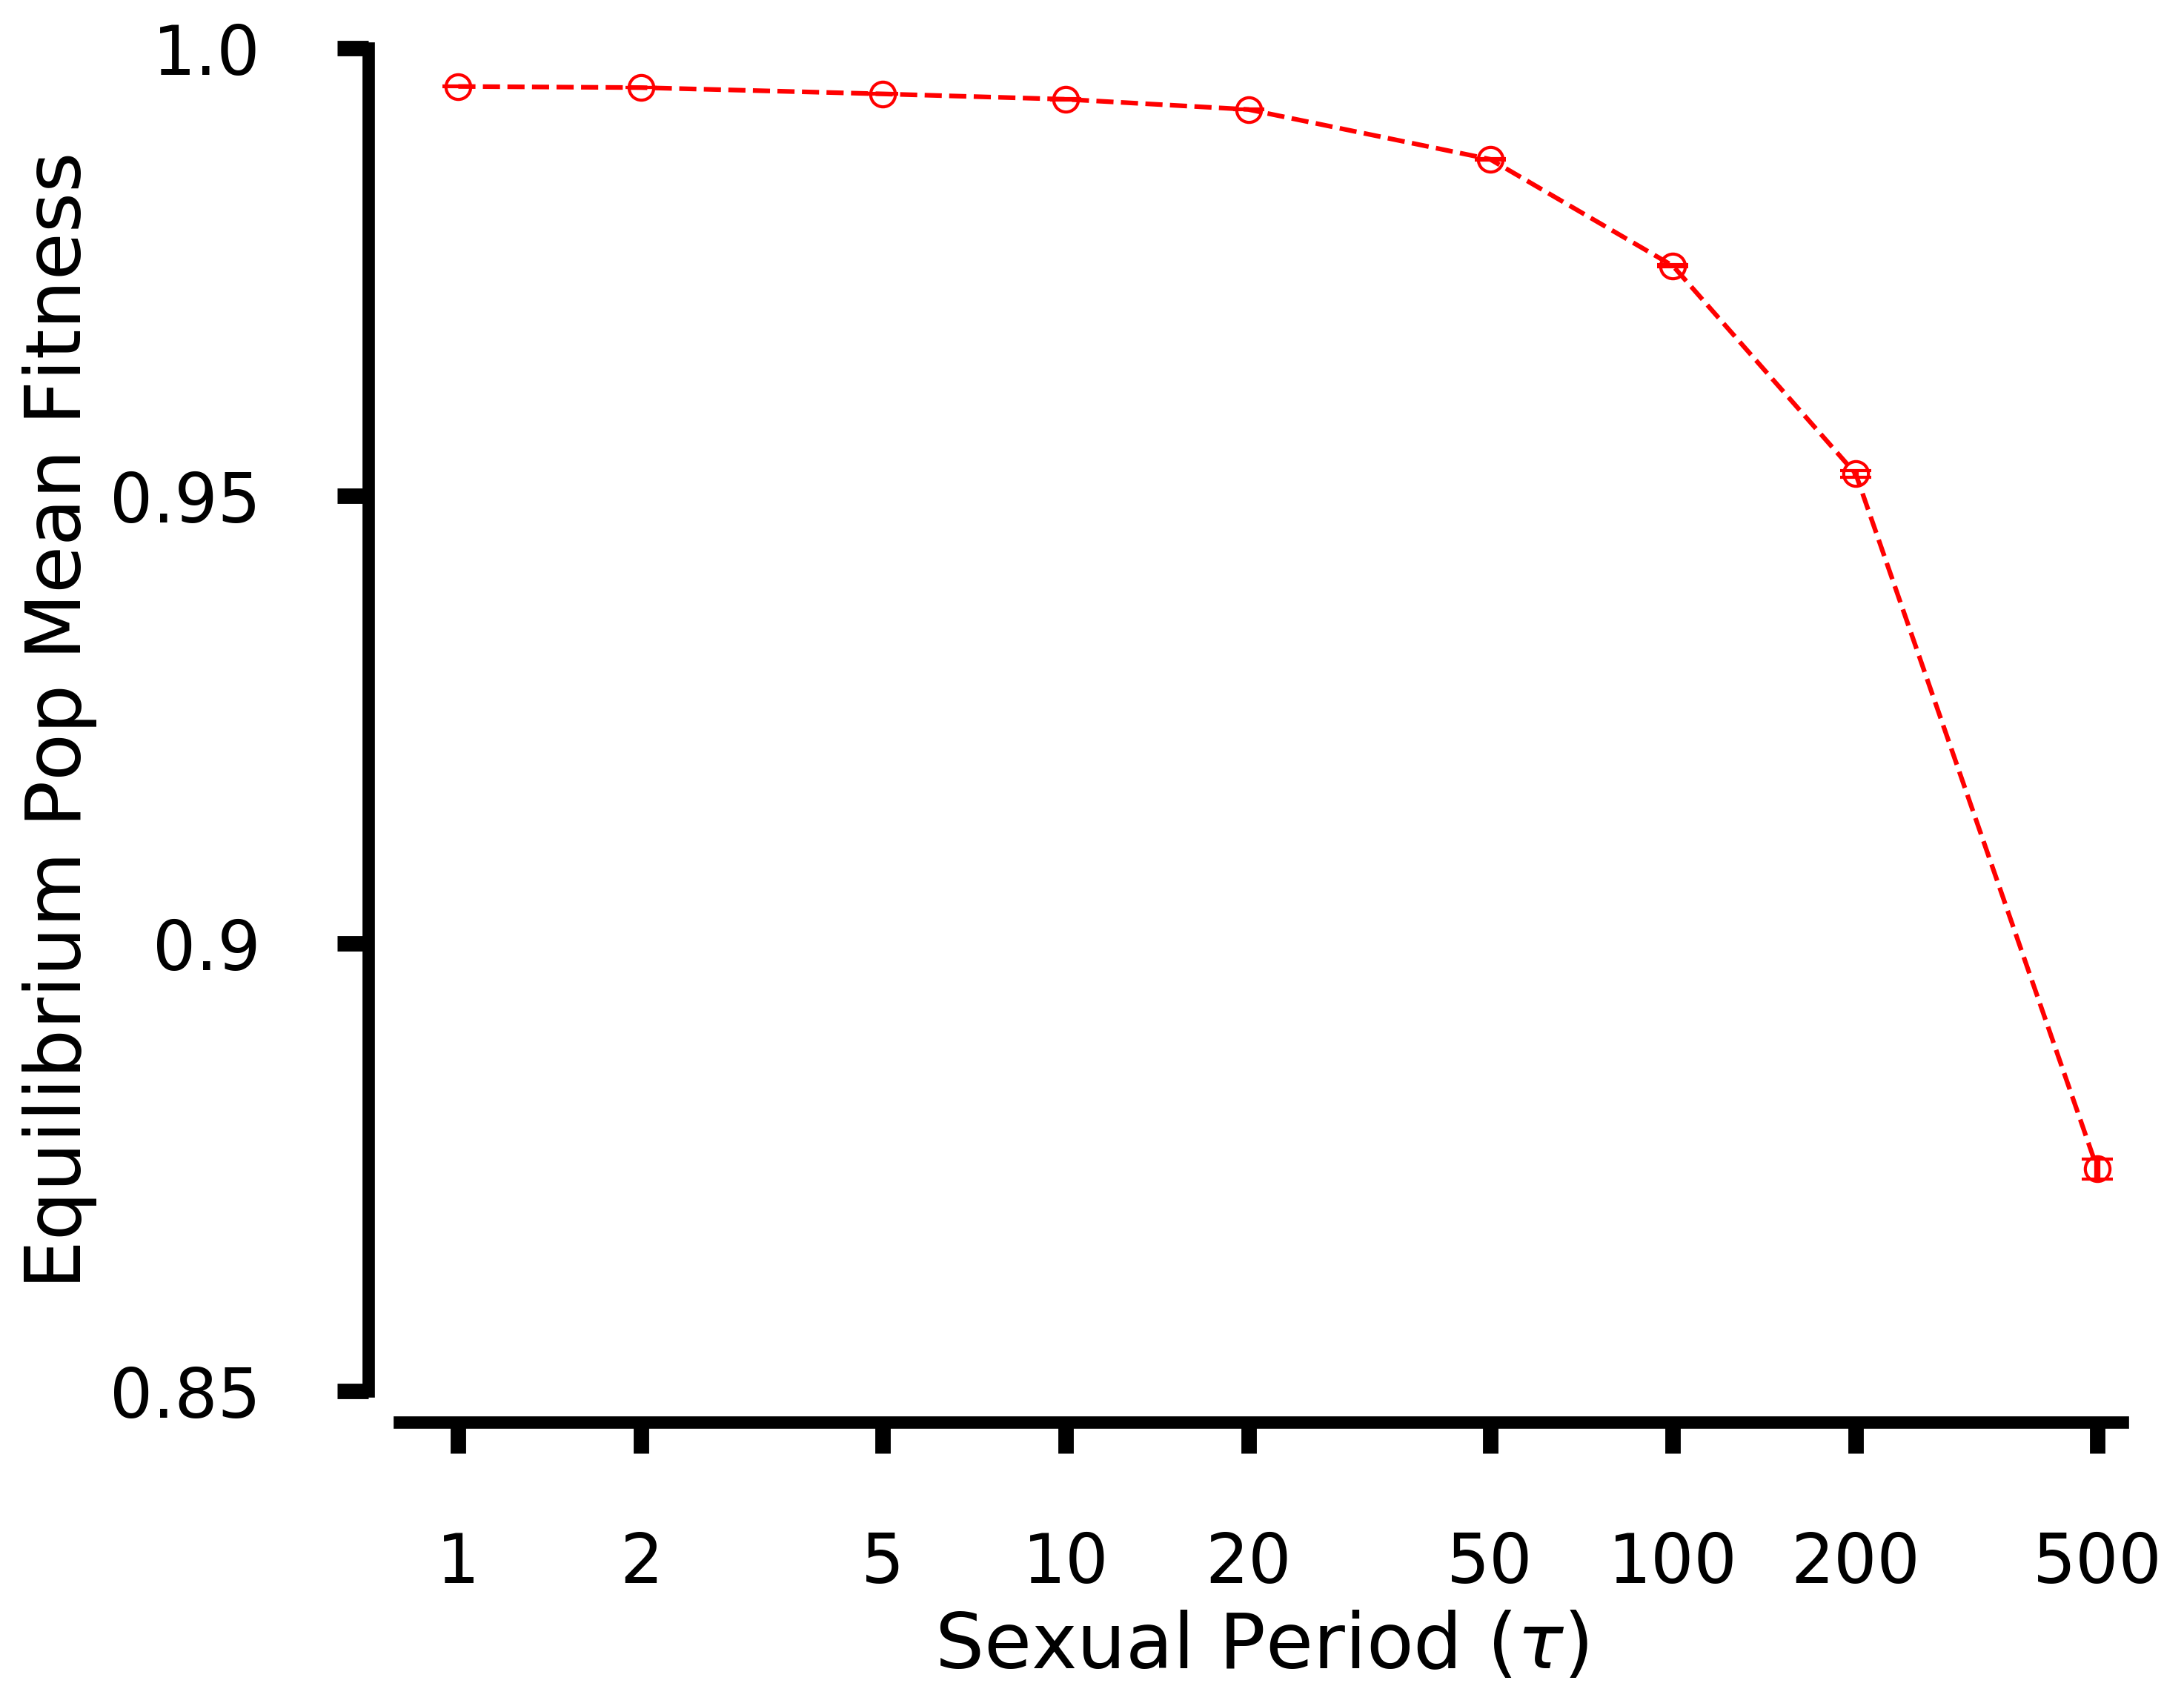

In [16]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

fig = plt.figure(figsize=(10,8), dpi =300)
ax = fig.add_subplot(111)
publication_figure_2(ax)

ax.set_ylim(0.85, 1.0)
ax.set_xlim(0.8,550)

x = [1, 2, 5, 10, 20, 50, 100, 200, 500]
ax.set_xscale('log',basex=2)

# N =100
y2 = np.array(rm2_mean)
yerr2 = 1.98*np.array(rm2_std)/((100)**0.5)
ax.errorbar(x, y2, yerr = yerr2, label ='Simulated Value', fmt='o', color = 'red', mfc='none', markersize =8, lw=2, capsize=5, capthick=1)
ax.plot(x,y2, color = 'red', ls = '--')




ax.set_xticks([1, 2, 5, 10, 20, 50, 100, 200, 500]) # choose which x locations to have ticks
ax.set_xticklabels([1, 2, 5, 10, 20, 50, 100, 200, 500]) # set the labels to display at those ticks


ax.set_yticks([0.85, 0.9, 0.95, 1]) # choose which x locations to have ticks
ax.set_yticklabels([ 0.85, 0.9, 0.95, 1.0]) # set the labels to display at those ticks


ax.set_xlabel(r'Sexual Period $(\tau)$', fontsize =25)
ax.set_ylabel('Equilibrium Pop Mean Fitness', fontsize =25)

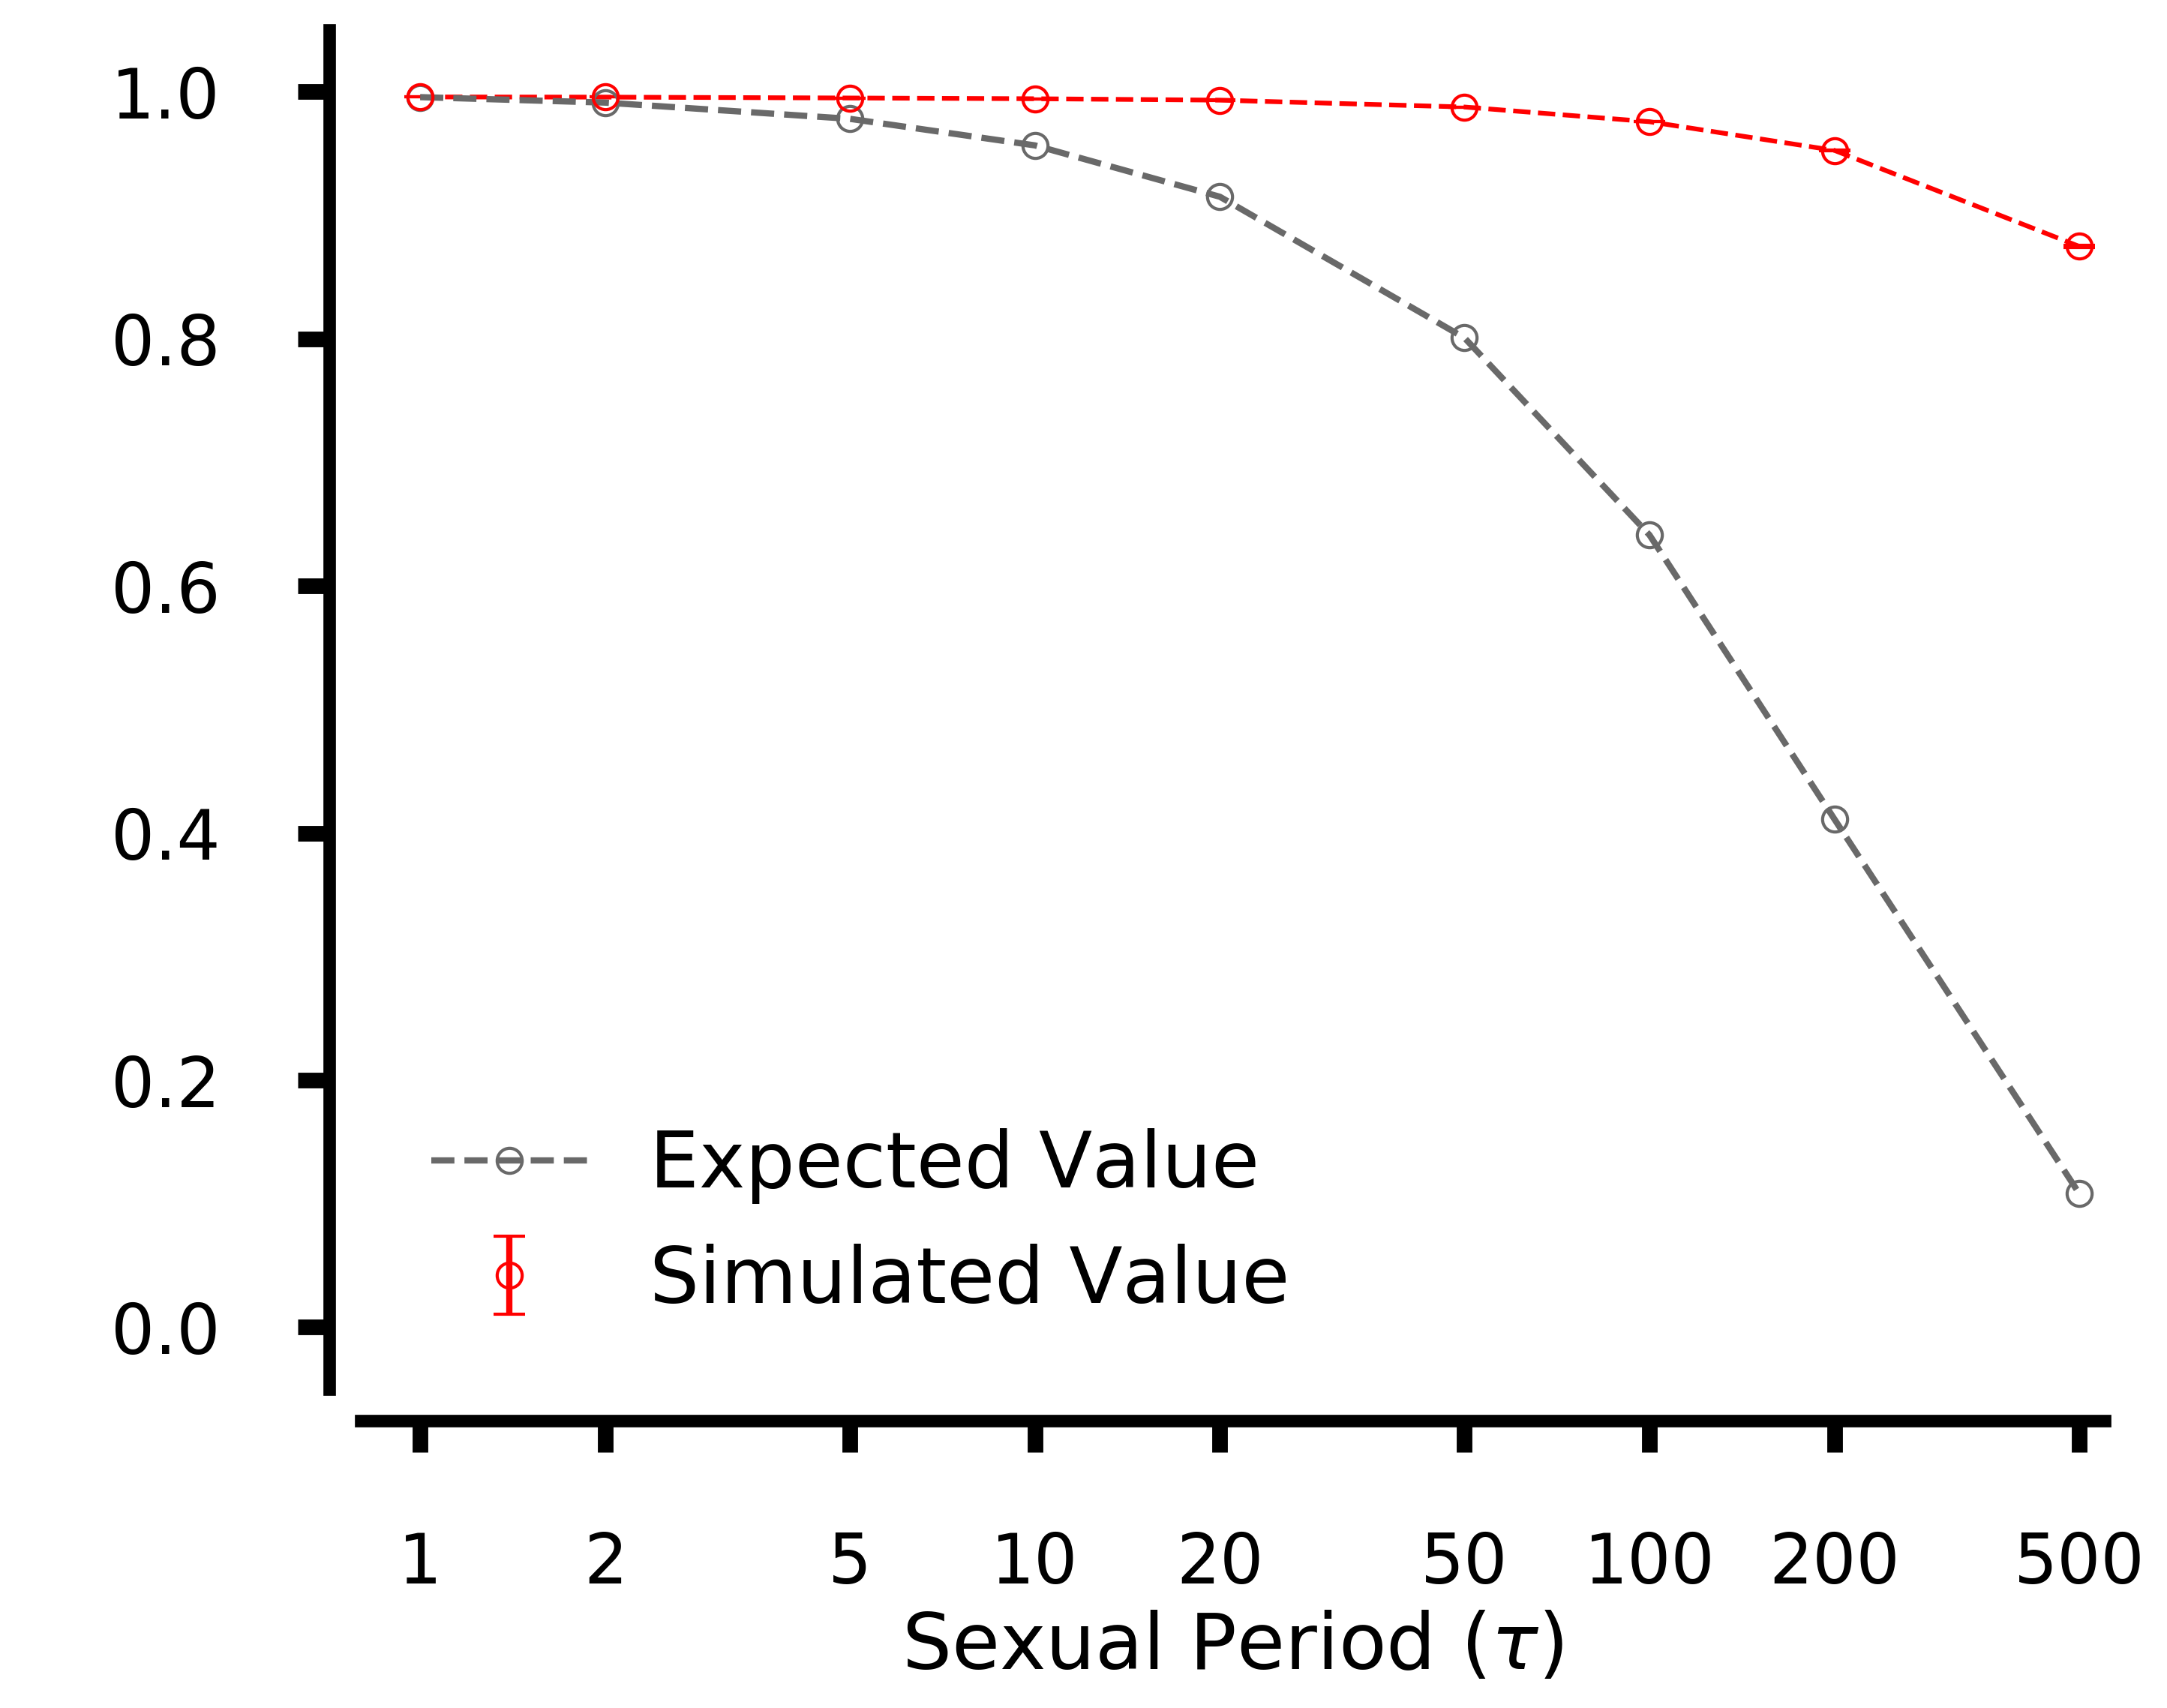

In [17]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

fig = plt.figure(figsize=(10,8), dpi =300)
ax = fig.add_subplot(111)
publication_figure_2(ax)

ax.set_ylim(-0.05, 1.05)
ax.set_xlim(0.8,550)

x = [1, 2, 5, 10, 20, 50, 100, 200, 500]
ax.set_xscale('log',basex=2)

# N =100
y2 = np.array(rm2_mean)
yerr2 = 1.96*np.array(rm2_std)/((100)**0.5)
ax.errorbar(x, y2, yerr = yerr2, label ='Simulated Value', fmt='o', color = 'red', mfc='none', markersize =8, lw=2, capsize=5, capthick=1)
ax.plot(x,y2, color = 'red', ls = '--')


# N =1000
y3 = np.array(expect_value)


ax.plot(x,y3, marker='o', label = 'Expected Value', mfc='none', markersize =8, lw =2, color = 'dimgrey', ls = '--',)

plt.legend(loc='lower left', frameon=False, prop={'size':25})

ax.set_xticks([1, 2, 5, 10, 20, 50, 100, 200, 500]) # choose which x locations to have ticks
ax.set_xticklabels([1, 2, 5, 10, 20, 50, 100, 200, 500]) # set the labels to display at those ticks


# ax.set_yticks([0.85, 0.9, 0.95, 1]) # choose which x locations to have ticks
# ax.set_yticklabels([ 0.85, 0.9, 0.95, 1]) # set the labels to display at those ticks


ax.set_xlabel(r'Sexual Period $(\tau)$', fontsize =25)
ax.set_ylabel('Equilibrium Pop Mean Fitness', fontsize =25, color = 'w')